In [1]:
import numpy as np
import pandas as pd
import emcee
import isochrones
from isochrones import SingleStarModel, get_ichrone
from isochrones.mist import MIST_EvolutionTrack, MIST_Isochrone
from isochrones.priors import FlatPrior, DistancePrior, AgePrior, FehPrior, AVPrior, EEP_prior, GaussianPrior
import isochrones.priors as isopro
import astropy.units as u
import matplotlib as mpl

from matplotlib.gridspec import GridSpec
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

from matplotlib import rcParams
rcParams['savefig.dpi'] = 550
rcParams['font.size'] = 20
mpl.rcParams['axes.linewidth'] = 1.8
plt.rc('font', family='serif')
%matplotlib inline
%config InlineBackend.figure_format = "retina"
from tqdm import tqdm
import matplotlib as mpl

print("isochrones:", isochrones.__version__)
print("emcee:     ", emcee.__version__)


isochrones: 2.1
emcee:      3.1.6


## Initialize MIST model Tracks

In [2]:
track = MIST_EvolutionTrack()

In [3]:
mist = get_ichrone('mist', bands=["BP", "G", "RP", 
                            "W1", "W2", "J", "H", "K"])

# Data from Tzanida et al. 2025
obs = {"G": (18.7862, 0.0028), 
       "BP": (19.6814, 0.0584),
       "RP": (17.7094, 0.0194),
       "H": (15.4460, 0.0210),
       "J": (16.1860, 0.0850),
       "K": (15.4080, 0.2100)}

mod = SingleStarModel(mist, name='Gaia-GIC-1-v1', **obs)

In [4]:
mod.observed_quantities

['G_mag', 'BP_mag', 'RP_mag', 'H_mag', 'J_mag', 'K_mag']

## Initialize model priors

- [Fe/H] **uniform** priror $\mathcal{U}$(-0.5, 0.5)
- distance **uniform** priror $\mathcal{U}$(3538,4688) based on [Bailer-Jones et al. 2021 ](https://ui.adsabs.harvard.edu/abs/2021AJ....161..147B/abstract). We will round our distance prior to (3000, 5000) pc.
- A $_{v}$  **uniform** priror $\mathcal{U}$(3.5, 4) based on the SFD dust extinction estimates at this line-of-sight [Schlegel et al. 1998](https://ui.adsabs.harvard.edu/abs/1998ApJ...500..525S/abstract). These estimates are also consistent with a possible open-cluster association FSR 1347 or FSR 1352 ([Hunt+ 2024](https://ui.adsabs.harvard.edu/abs/2024A%26A...686A..42H/abstract))
- We will assume a broad uniform Age prior $\mathcal{U}$(6, 9.8)


In [5]:
mod.set_prior(feh=FlatPrior((-0.5, 0.5)),
    distance=FlatPrior((3_000, 5_000)), 
             AV=FlatPrior((3.5, 4)),
             )

In [6]:
# path where chains are saved
mod.mnest_basename

'./chains/Gaia-GIC-1-v1-mist-single-'

In [18]:
mod.fit(n_live_points=3_000)

 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points = 3000
 dimensionality =    5
 resuming from previous job
 *****************************************************
 Starting MultiNest
Acceptance Rate:                        0.232750
Replacements:                              46435
Total Samples:                            199506
Nested Sampling ln(Z):                -66.736536
Importance Nested Sampling ln(Z):     -67.632620 +/-  0.058023
 ln(ev)=  -66.598416859347608      +/-   6.0232192141518835E-002
 Total Likelihood Evaluations:       199506
 Sampling finished. Exiting MultiNest


/opt/miniconda3/envs/astrobase2/lib/python3.9/site-packages/isochrones/starmodel.py:1645: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(filename, names=self.param_names + ("lnprob",), delim_whitespace=True)


In [8]:
mod.samples.head()

,eep,age,feh,distance,AV,lnprob
0,394.555175,9.594213,0.026248,3025.000744,3.778542,-64.148335
1,449.529097,9.853469,-0.383117,3337.263228,3.583954,-64.141154
2,382.233489,9.320074,0.320315,4803.980881,3.593605,-64.020661
3,433.255394,9.632367,-0.220736,3415.951564,3.886262,-63.749144
4,215.062671,7.405169,0.189481,3167.113467,3.854102,-63.561129


In [9]:
mod.samples.describe()

,eep,age,feh,distance,AV,lnprob
count,15296.000000,15296.000000,15296.000000,15296.000000,15296.000000,15296.000000
mean,396.803141,9.455747,-0.096547,3671.760664,3.803019,-55.709873
std,39.319737,0.255361,0.268766,508.364141,0.139179,1.237588
min,178.687306,6.794057,-0.499791,3000.187037,3.500082,-64.148335
25%,370.542356,9.332058,-0.319488,3244.418004,3.693983,-56.311056
50%,389.739716,9.456000,-0.139969,3555.323416,3.830393,-55.495235
75%,436.487904,9.636413,0.105674,3998.648536,3.923257,-54.864680
max,461.810439,9.992702,0.499928,4999.951600,3.999993,-52.951748


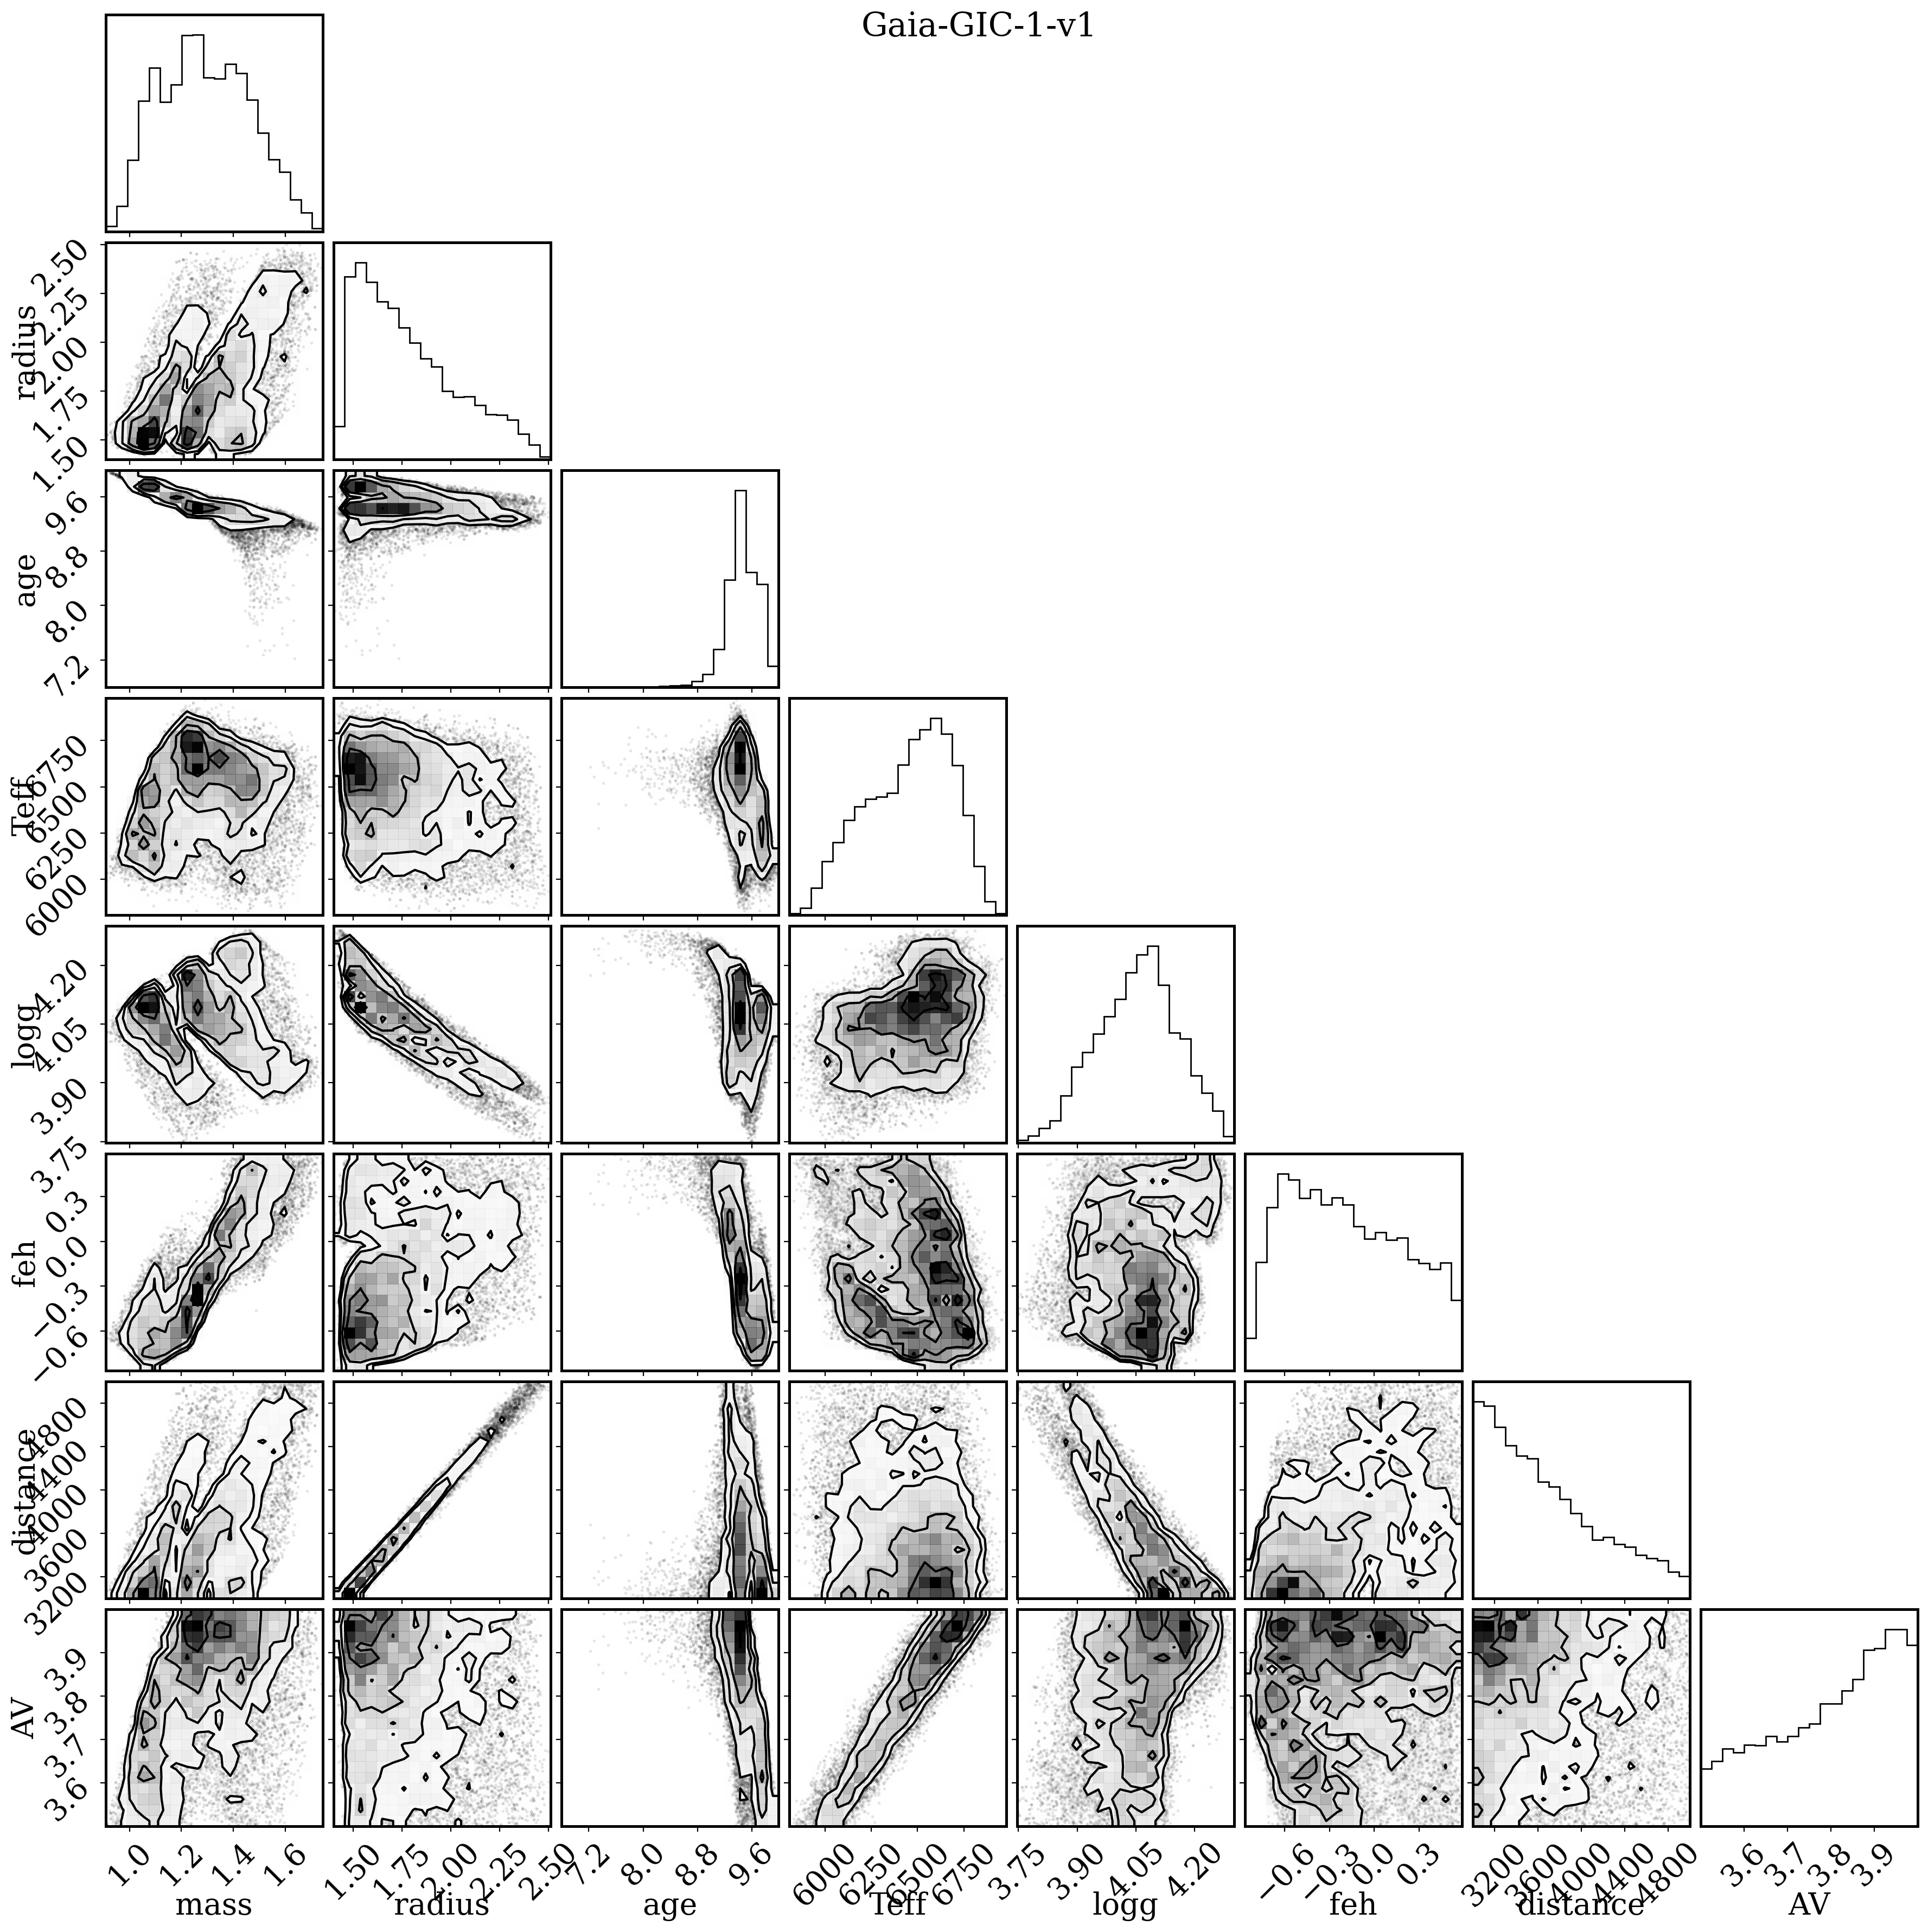

In [10]:
_ = mod.corner_physical()


/var/folders/xk/5g8l6b0d4r1dyg5f01jbjj800000gn/T/ipykernel_89763/68066778.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


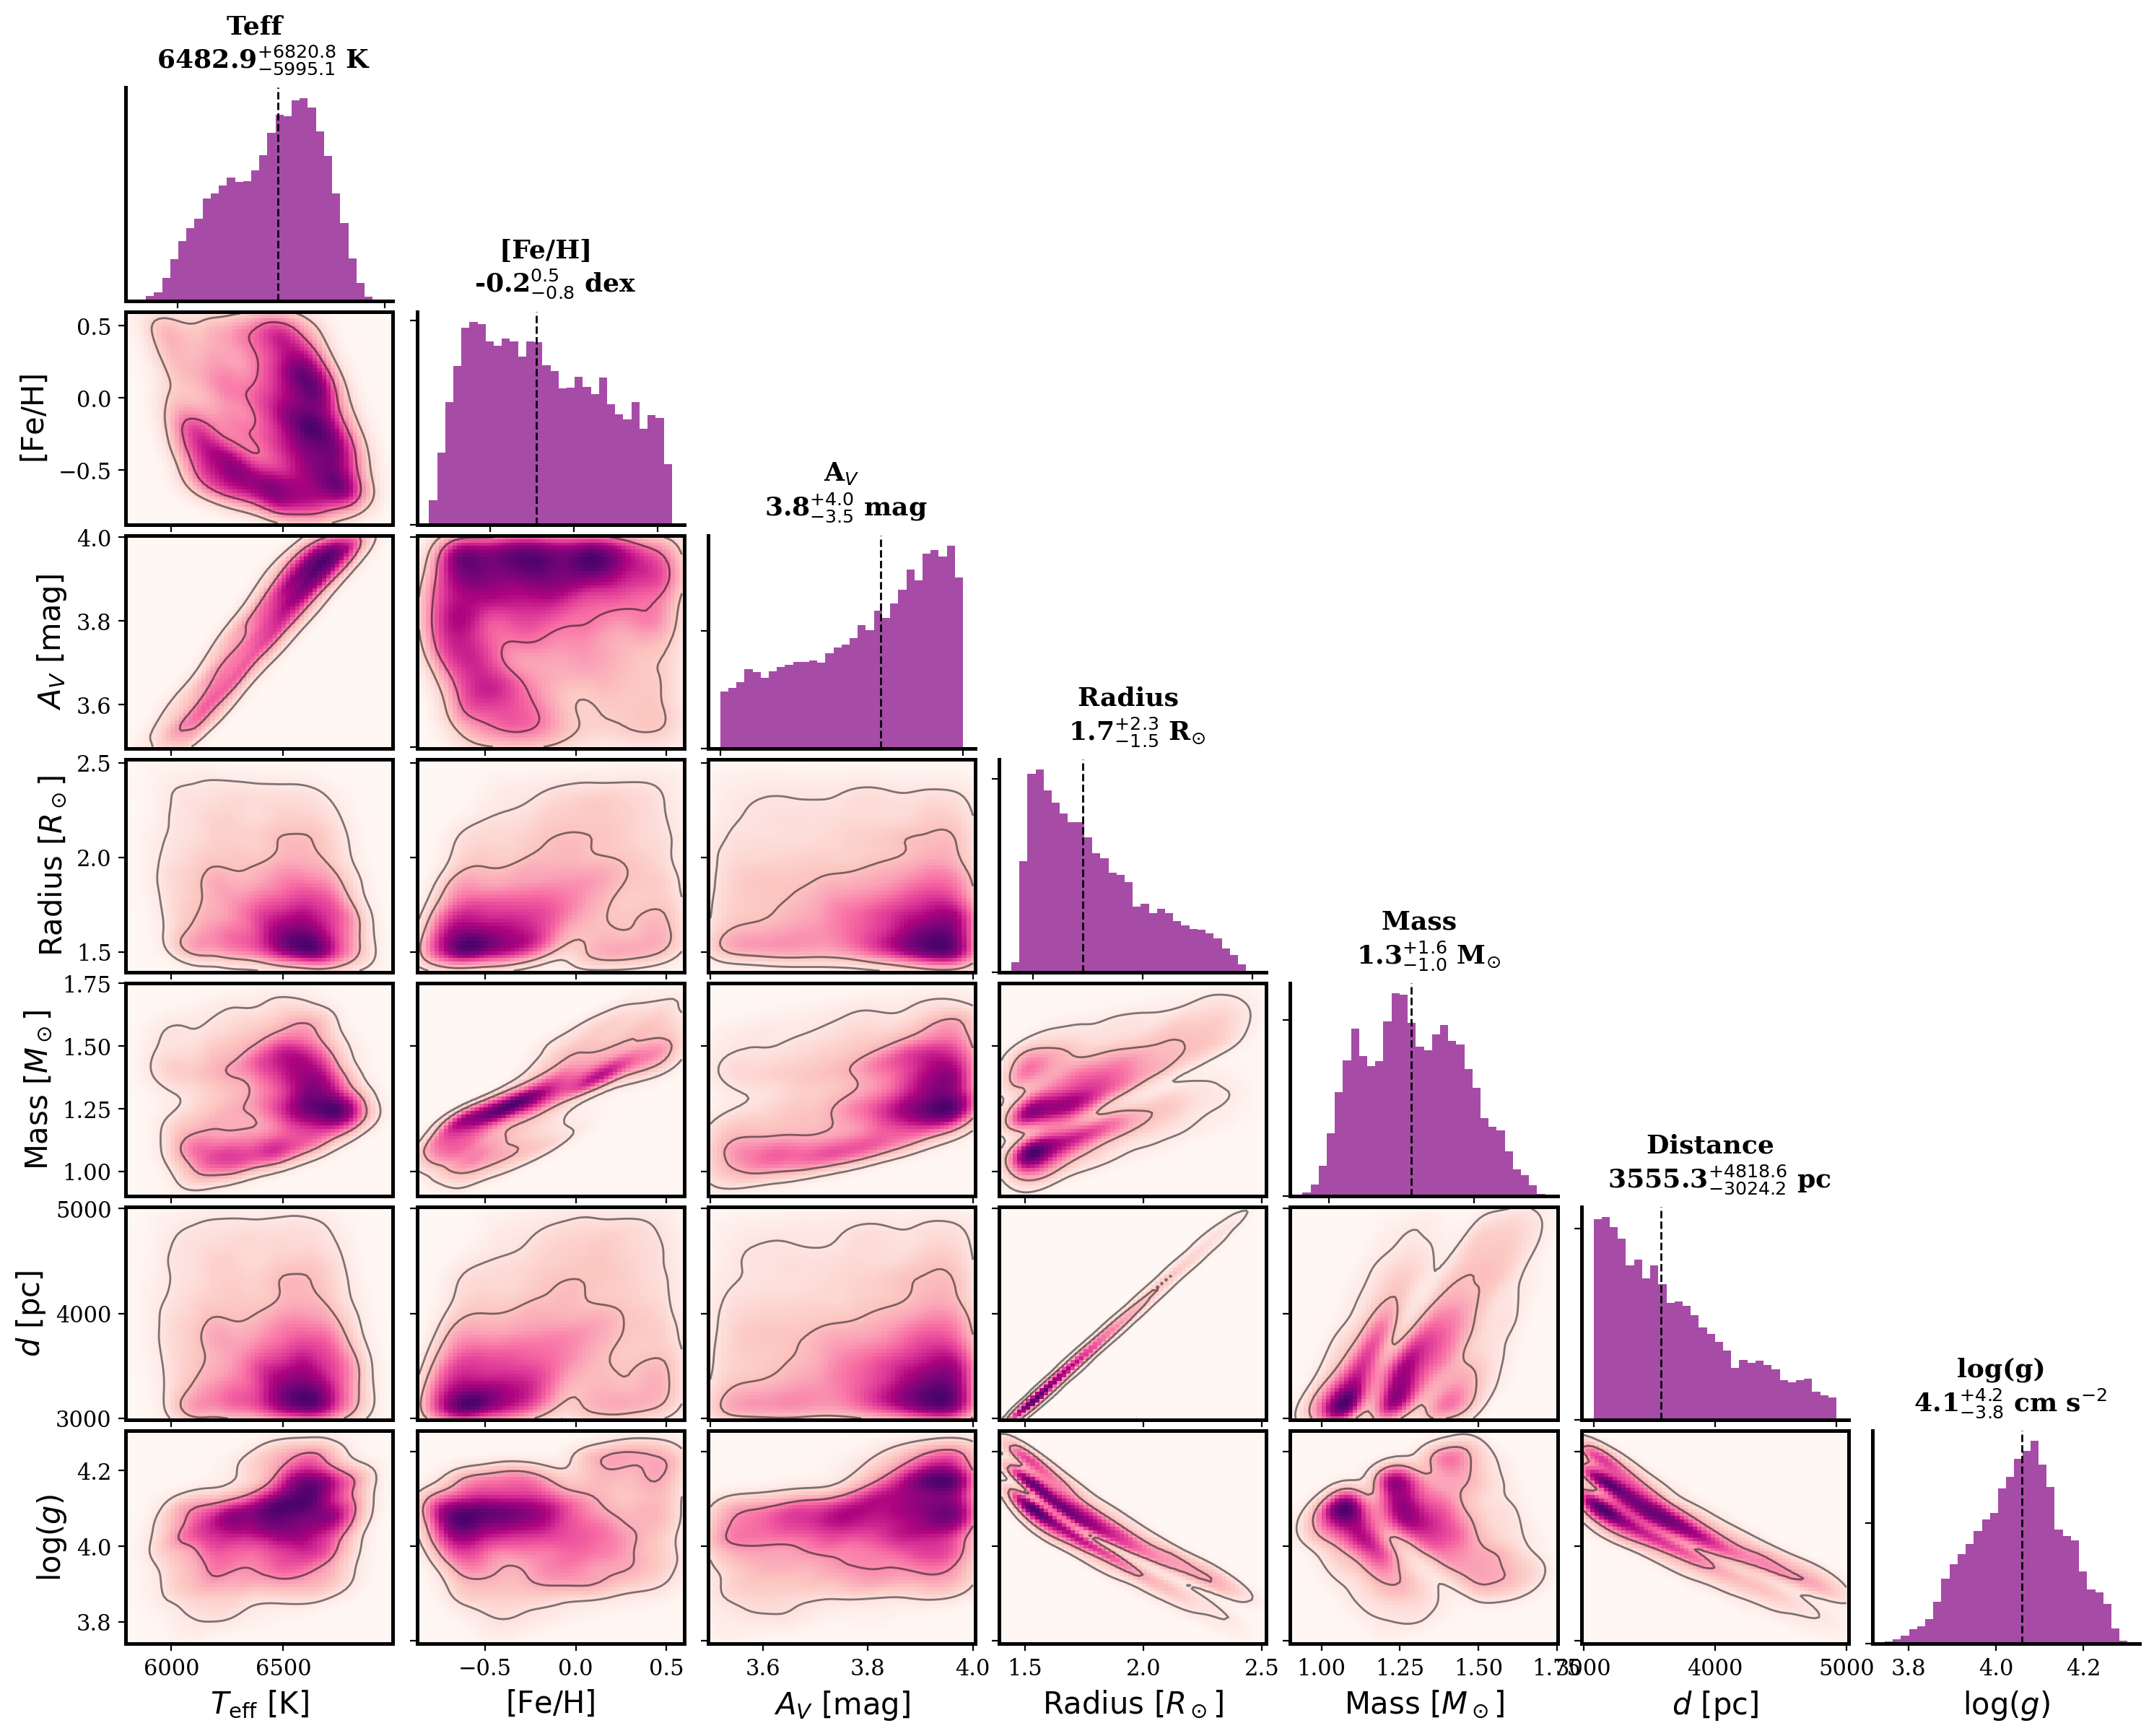

In [ ]:
# columns to include in corner plot
cols_of_interest = ['Teff', "feh", "AV", "radius", "mass", "distance", "logg"]
full_samp = mod.derived_samples[cols_of_interest].to_numpy() # select only relevant columns

ndim = full_samp.shape[1] # shape of parameter space

labels = [
    r"$T_{\mathrm{eff}}\ [\mathrm{K}]$",
    r"$\mathrm{[Fe/H]}$",
    r"$A_V\ [\mathrm{mag}]$",
    r"$\mathrm{Radius}\ [R_\odot]$",
    r"$\mathrm{Mass}\ [M_\odot]$",
    r"$d\ [\mathrm{pc}]$",
    r"$\log(g)$"
    ]

label_names = [
    "Teff", "[Fe/H]", "A$_V$", "Radius", "Mass", "Distance", "log(g)"
    ]

units = [
    "K", "dex", "mag", "R$_{\odot}$", "M$_{\odot}$", "pc", "cm s$^{-2}$"
    ]


def plot_kde_smoothed(ax, x, y, gridsize=60, levels=(0.682, 0.954), cmap='RdPu'):
    """Plot 2D KDE smoothed density and contours on an Axes.
    
    Parameters
    ----------
    ax : matplotlib Axes
        The axes on which to plot.
    x : np.array
        x data points.
    y : np.array
        y data points.
    gridsize : int, optional
        Number of grid points along each axis, by default 60
    levels : tuple, optional
        Contour levels to plot, by default (0.682, 0.954)
    cmap : str, optional
        Colormap to use, by default 'RdPu'
    """
    values = np.vstack([x, y])
    kde = gaussian_kde(values) # gaussian kernel density estimate

    xi, yi = np.mgrid[x.min():x.max():gridsize*1j, y.min():y.max():gridsize*1j]
    zi = kde(np.vstack([xi.ravel(), yi.ravel()])).reshape(xi.shape) # apply KDE

    ax.pcolormesh(xi, yi, zi, shading='auto', cmap=cmap, alpha=0.99)

    z_sorted = np.sort(zi.ravel())
    z_cumsum = np.cumsum(z_sorted)
    z_cumsum /= z_cumsum[-1] # normalize to 1

    contour_levels = sorted([z_sorted[np.searchsorted(z_cumsum, 1 - lvl)] for lvl in levels])

    ax.contour(xi, yi, zi, levels=contour_levels, colors='black', linewidths=1, alpha=0.5)

w_dim, h_dim = 0.09, 0.05 # dimensions of sub-grid spacing
fig = plt.figure(figsize=(18,14))
gs = GridSpec(ndim, ndim, figure=fig, wspace=w_dim, hspace=h_dim)

for i in range(ndim):
    for j in range(ndim):
        ax=fig.add_subplot(gs[i, j])

        if i == j:
            data = full_samp[:, j]
            cmap_style = "purple"
            ax.hist(data, bins=30, color=cmap_style, alpha=0.7, density=True)

            median = np.median(data)
            sigma = np.std(data)
            percentiles = np.percentile(data, [2.28, 50, 97.7]) # 2-sigma percentiles

            name = label_names[j]
            unit = units[j]

            # Format label text with percentiles
            if unit=='dex':
                label_text = f"{name} \n {percentiles[1]:.1f}$^{{{percentiles[2]:.1f}}}_{{{percentiles[0]:.1f}}}$ {unit}"
            else:
                label_text = f"{name} \n {percentiles[1]:.1f}$^{{+{percentiles[2]:.1f}}}_{{-{percentiles[0]:.1f}}}$ {unit}" 

            ax.axvline(median, color='k', ls='--', lw=1)
            ax.set_title(label_text, fontsize=13, pad=10, weight='bold')

            ### Remove top and right spines ### 
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

        elif i > j:
            x = full_samp[:, j]
            y = full_samp[:, i]
            plot_kde_smoothed(ax, x, y)

        else:
            ax.axis('off')

        if i == ndim - 1 and j <= i:
            ax.set_xlabel(labels[j], fontsize=15)
            ax.tick_params(axis='x', labelsize=11)
        else:
            ax.set_xticklabels([])

        if j == 0 and i >= j:
            ax.set_ylabel(labels[i], fontsize=15)
            ax.tick_params(axis='y', labelsize=11)
        else:
            ax.set_yticklabels([])

        if i == 0 and j == 0:
            ax.set_yticks([])
            ax.set_ylabel("")
            
plt.tight_layout()